# **PLANIFICACIÓN DE UNA BASE DE DATOS: ACUEDUCTO DEL MUNICIPIO DE DOTA**

El Departamento de Acueducto del municipio de Dota actualmente no contempla un sistema para la gestión de activos de los sistemas de agua de las comunidades que tiene a cargo. Dispone de levantamientos topográficos en algunos sectores, pero no es su totalidad, lo que ha obstaculizado la adquisición de recursos y financiamiento.  
Dicha limitación en gestión, hace que la **generación de inventarios, materiales en stock y el desarrollo de presupuestos** se haga de forma empírica, al no contar con información base.  
En cuanto a funcionamiento, la captación del recurso se realiza por **nacientes de agua**, conformando el sistema por la tubería de conducción hasta los tanques de almacenamiento y brindar el servicio a los hogares mediante la tubería de distribución. El acueducto contempla **macromedidores en nueve sectores, válvulas, hidrantes y los micromedidores** en las tomas domiciliares. Disponen de un sistema de búsqueda por número de medidor para realizar los cobros, el cual se encarga una funcionaria del departamento para realizarlo. El acueducto municipal brinda el servicio en el centro de *Santa María, El Jardín y de Copey*.

## **Conformación de la base de datos**

La base inicial se compondrá con el sector denominado ***"Rubén"***, siendo de importancia para la comunidad de Santa María.  
Para la conformación de la base de datos se dispone de los siguientes componentes con las variables respectivas:

* Válvula: {**codigo_valvula**, tipo, presión, cumplimiento, estado, fecha_mantenimiento, fecha_instalación, id_tuberia}
* Naciente: {**id_naciente**, nombre}
* Hidrante: {**codigo_hidrante**, pobl_servicio, estado, fecha_mantenimiento, fecha_instalación, id_tuberia}
* Tubería: {**id_tuberia**, diámetro_pulgadas, diámetro_milímetros, material, distancia, estado, fecha_mantenimiento, fecha_instalacion, id_tanque}
* Tanque: {**id_tanque**, capacidad, nombre, material, estado, fecha_mantenimiento, fecha_instalación, id_naciente}
* Medidor: {**numero_medidor**, numero_finca, estado, fecha_mantenimiento, fecha_instalación, id_tuberia, latitud, longitud, cedula}
* Macromedidor: {**codigo_macro**, caudal, estado, fecha_mantenimiento, fecha_instalación, id_tuberia}
* Cliente: {**cedula**, nombre}  

Es necesario indicar que **no todas las variables se encuentran dentro del sector**, por lo que las variables naciente, macromedidor, hidrante y tanque se excluyen, para efectos del presente ejercicio.

## **Base de datos de los activos**

#### Configuración y carga de datos

In [33]:
import pandas as pd

In [34]:
url1= "https://raw.githubusercontent.com/Vivian-M/Tarea-02/refs/heads/main/medidores.csv"
medidores = pd.read_csv(url1, sep=";")

In [35]:
print(medidores.head())

   FID  Tipo  #_medidor  numero_fin   estado  fecha_mant  fecha_inst  \
0    0     1          1      206980    Bueno  12/10/2022  28/11/2001   
1    1     1          2      100442  Regular   31/8/2023   29/8/2008   
2    2     1          3      440633    Bueno    5/6/2020   17/5/2001   
3    3     1          4      163771  Regular    1/4/2020   30/7/2002   
4    4     1          5      579851    Bueno  13/12/2023    9/7/2007   

   id_tuberia      Latitud    Longitud  
0          34  1067182,122   504011,43  
1          34   1067180,97  504014,685  
2          34   1067179,18  504019,668  
3          34  1067178,174  504022,658  
4          34    1067175,4  504030,691  


In [36]:
url2="https://raw.githubusercontent.com/Vivian-M/Tarea-02/refs/heads/main/Tuberias.csv"
tuberias = pd.read_csv(url2, sep=";")

In [37]:
url3="https://raw.githubusercontent.com/Vivian-M/Tarea-02/refs/heads/main/Valvulas.csv"
valvulas = pd.read_csv(url3, sep=";")

In [38]:
url4="https://raw.githubusercontent.com/Vivian-M/Tarea-02/refs/heads/main/Clientes.csv"
clientes = pd.read_csv(url4, sep=";")

In [39]:
print(valvulas.head())

   ID  Tipo  Presion Cumplimiento   Estado  Fecha_mant Fecha_inst  \
0  22     6        8    No cumple    Bueno  30/12/2021  20/9/2022   
1  24     5       12       Cumple  Regular   2/12/2020  20/9/2022   
2  25     5       18       Cumple    Bueno   20/2/2023  20/9/2022   
3  26     1       25       Cumple    Bueno   21/5/2020  20/9/2022   
4  27     1       32       Cumple    Bueno   22/8/2022  20/9/2022   

       Latitud    Longitud  id_tuberia  
0  1067955,519  505601,752          31  
1  1067486,282  504990,196          31  
2  1067370,209  504744,252          28  
3  1067151,763  504847,016          32  
4  1067118,286  504806,522          32  


In [40]:
# Limpieza de espacios en archivos
clientes.columns = clientes.columns.str.strip()
medidores.columns = medidores.columns.str.strip()
tuberias.columns = tuberias.columns.str.strip()
valvulas.columns = valvulas.columns.str.strip()

In [41]:
# Verificación de lectura
print(medidores["#_medidor"].head(10))
print(medidores["#_medidor"].dtype)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: #_medidor, dtype: int64
int64


### Resumen del estado de las válvulas

##### Tabla de agrupamiento de valores (conteo)

In [42]:
# Agrupamiento
tabla1 = valvulas.groupby(["Cumplimiento", "Estado"]).size().reset_index(name="Cantidad")

In [43]:
print(tabla1)

  Cumplimiento   Estado  Cantidad
0       Cumple    Bueno         9
1       Cumple  Regular         4
2    No cumple    Bueno         7


El buen funcionamiento de las válvulas es necesario para el mantenimiento de las presiones y evitar daños en las tuberías. Se deberá destinar presupuesto para mejorar aquellos activos que se encuentran en un estado regular y mejorar el diseño (colocación de más válvulas) en los puntos de control donde no cumple con las presiones reglamentadas.

### Longitud total por material

#### Agrupamiento de datos por sumatoria

In [44]:
# Agrupar por material y sumar longitud
tabla_total = tuberias.groupby("Material")["Longitud"].sum().reset_index()

print(tabla_total)

  Material  Longitud
0     PEAD  1366.301
1      PVC  4623.543


Se requiere la sustitución de 4623.54 metros de tubería por PEAD, siendo este un material más adaptable y resistente.

### Filtrado de medidores con mantenimiento reciente pero en estado regular o malo

#### Listado de medidores por características solicitadas

In [45]:
# Convertir fecha de mantenimiento
medidores["fecha_mant"] = pd.to_datetime(medidores["fecha_mant"],dayfirst=True)

# Filtrar estado Regular o Malo y mantenimiento desde 2022
medidores_filtrados = medidores[
    ((medidores["estado"] == "Regular") | (medidores["estado"] == "Malo")) & (medidores["fecha_mant"].dt.year >= 2022)
    ][["#_medidor", "fecha_mant", "estado"]]

print(medidores_filtrados)

     #_medidor fecha_mant   estado
1            2 2023-08-31  Regular
14          15 2022-07-06  Regular
17          18 2023-01-27  Regular
22          23 2022-03-03  Regular
26          27 2024-01-29  Regular
43          44 2024-01-26     Malo
71          72 2022-05-09  Regular
72          73 2024-09-18  Regular
80          81 2024-12-11  Regular
88          89 2023-03-30  Regular
105        106 2023-06-05     Malo
115        116 2024-04-12  Regular
123        124 2022-07-15  Regular


Mediante el identificador de los medidores se puede programar un nuevo mantenimiento de aquellos medidores que se encuentran en estado regular y verificar los que se reportaron en mal funcionamiento.

### Visualización por gráficos

In [46]:
# Carga del módulo pyplot de matplotlib con el alias plt
import matplotlib.pyplot as plt

# Módulo para configurar las marcas ("ticks") de los ejes de los gráficos
from matplotlib import ticker

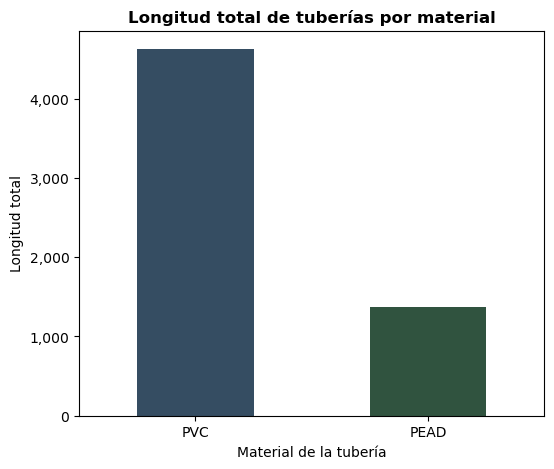

In [47]:

# Gráfico de barras (espacio)
fig, ax = plt.subplots(figsize=(6, 5))

# Suma de longitud por material
longitud_material_suma = tuberias.groupby('Material')['Longitud'].sum()

# Creación del gráfico de barras
longitud_material_suma.sort_values(
    ascending=False).plot.bar(
    ax=ax,
    color=["#354D62", "#30533F"],
    width=0.5,
    rot=0)
# Datos del gráfico
ax.set_title('Longitud total de tuberías por material',  fontweight='bold')
ax.set_xlabel('Material de la tubería')
ax.set_ylabel('Longitud total')

# Configuración de marcas en los ejes
ax.yaxis.set_major_formatter( ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

La cantidad de metros lineales de tubería de PVC se encuentra muy presente como material recurrente del acueducto. El municipio deberá de evaluar la posibilidad de cambiar todo el sector a PEAD o analizar si realizar el cambio en los sectores donde se tenga mayor riesgo de roturas o pérdida de material.

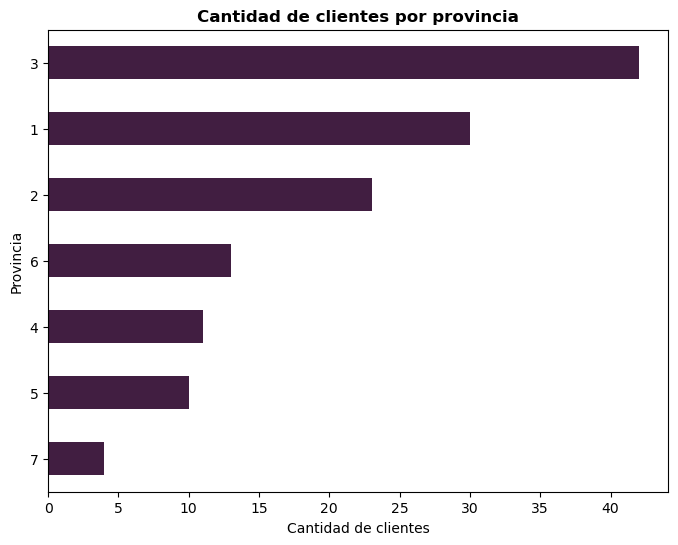

In [48]:
# Obtener provincia desde el primer número de la cédula
clientes['Provincia'] = clientes['Cedula'].str[0]

# Contar clientes por provincia
clientes_provincia = clientes.groupby('Provincia').size()

# Creación de una figura con espacio para un gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Creación del gráfico de barras horizontal
clientes_provincia.sort_values().plot.barh(
    ax=ax,
    color="#411E41")

# Personalización del gráfico
ax.set_title('Cantidad de clientes por provincia',  fontweight='bold')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('Provincia')

# Configuración de marcas en los ejes
ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}'))

# Despliegue del gráfico
plt.show()

Este gráfico es general y referente a la procedencia de los habitantes. Es normal que la procedencia relativa a Cartago y San José (sean personas propias del cantón), mientras que los otros grupos pueden responder a personas que se han instalado en Santa María (normalmente clientes transitorios).

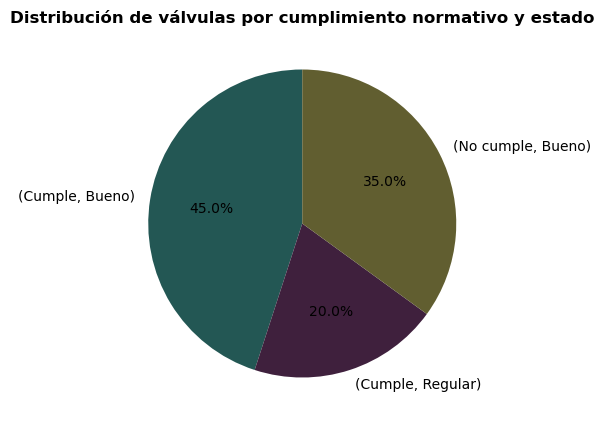

In [49]:
# Agrupamiento de válvulas por cumplimiento y estado
valvulas_agrupadas = valvulas.groupby(
    ['Cumplimiento', 'Estado']).size()

# Creación de una figura con espacio para un gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# Creación del gráfico de barras
# Es recomendable que las barras se muestren en orden
valvulas_agrupadas.plot.pie(
    ax=ax,
      autopct='%1.1f%%',
    startangle=90,
    colors= ['#235754', "#3F203D", "#615E30"],)

# Título del gráfico
ax.set_title('Distribución de válvulas por cumplimiento normativo y estado',
 fontweight='bold')

plt.show()

El 35% del sistema posee una situación crítica que debe de solventarse en prevedad mediante la instalación de más válvulas o mejorando el diseño del acueducto, a pesar de que las válvulas se encuentren funcionando correctamente. Un 20% pasa a una prioridad media donde podría solventarse en los periodos de mantenimiento del sistema.